# HW3: Self-Supervised Learning на базе HW1

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import accuracy_score

import seaborn as sns
import copy


D:\setup\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# 1. Установка seed-ов и базовых параметров

In [2]:
def set_random_seed(seed: int):
    """
    Устанавливаем seed для всех генераторов случайных чисел
    для обеспечения воспроизводимости результатов
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_random_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cuda


# 2. FeatureExtractor

In [3]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = SimpleResNet18(num_classes=10)
        self.conv1 = base.conv1
        self.bn1   = base.bn1
        self.layer1= base.layer1
        self.layer2= base.layer2
        self.layer3= base.layer3
        self.layer4= base.layer4
        # Не включаем base.fc, т.к. хотим вектор фичей на выходе

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.adaptive_avg_pool2d(out, 1)  # <--- теперь это безопасно
        out = out.view(out.size(0), -1)      # => (B,512)
        return out

# 3. Dataset для self-supervised (Context Prediction)

In [4]:
class ContextPredictionDataset(torch.utils.data.Dataset):
    def __init__(self, cifar_dataset, patch_size=14, gap=4):
        self.dataset = cifar_dataset
        self.patch_size = patch_size
        self.gap = gap
        self.rel_positions = [
            (-1, -1),
            (-1,  0),
            (-1,  1),
            ( 0, -1),
            ( 0,  1),
            ( 1, -1),
            ( 1,  0),
            ( 1,  1),
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]  # img.shape [C,32,32]
        # Для простоты: берём Tensor без лишних transform

        ps = self.patch_size
        g  = self.gap
        C, H, W = img.shape

        # Первый патч
        max_x = W - ps
        max_y = H - ps
        x1 = random.randint(0, max_x)
        y1 = random.randint(0, max_y)

        pos_idx = random.randint(0, 7)
        dx, dy = self.rel_positions[pos_idx]

        x2 = x1 + dy*(ps + g)
        y2 = y1 + dx*(ps + g)
        # clamp, чтобы не вылезти
        x2 = max(0, min(x2, max_x))
        y2 = max(0, min(y2, max_y))

        patch1 = img[:, y1:y1+ps, x1:x1+ps]
        patch2 = img[:, y2:y2+ps, x2:x2+ps]
        return patch1, patch2, pos_idx

# 4. Модель ContextPrediction: shared ResNetFeatureExtractor + fc

In [5]:
class ContextPredictionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = ResNetFeatureExtractor()
        self.fc = nn.Sequential(
            nn.Linear(512*2, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )

    def forward(self, patch1, patch2):
        f1 = self.feature_extractor(patch1)
        f2 = self.feature_extractor(patch2)
        cat = torch.cat([f1, f2], dim=1)
        out = self.fc(cat)
        return out

# 5. Функция обучения self-supervised

In [6]:
def train_context_model(model, train_loader, val_loader, num_epochs=5, lr=1e-3, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_model = copy.deepcopy(model.state_dict())
    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        model.train()
        correct = 0
        total = 0
        for (p1, p2, y) in train_loader:
            p1, p2, y = p1.to(device), p2.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(p1, p2)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            _, pred = torch.max(outputs, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        train_acc = 100.0 * correct / total

        model.eval()
        correct_v, total_v = 0, 0
        with torch.no_grad():
            for (p1, p2, y) in val_loader:
                p1, p2, y = p1.to(device), p2.to(device), y.to(device)
                outputs = model(p1, p2)
                _, pred = torch.max(outputs, 1)
                correct_v += (pred == y).sum().item()
                total_v += y.size(0)
        val_acc = 100.0 * correct_v / total_v

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model)
    return train_acc_history, val_acc_history

# 6. Готовим датасеты и dataloader

In [7]:
full_cifar_train = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
train_size = int(0.9*len(full_cifar_train))
val_size   = len(full_cifar_train) - train_size
train_dataset_cifar, val_dataset_cifar = random_split(
    full_cifar_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

context_train_dataset = ContextPredictionDataset(train_dataset_cifar)
context_val_dataset   = ContextPredictionDataset(val_dataset_cifar)

train_loader_context = DataLoader(context_train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader_context   = DataLoader(context_val_dataset,   batch_size=64, shuffle=False, num_workers=0)

Files already downloaded and verified


# 7. Запускаем self-supervised обучение

In [8]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class SimpleResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(SimpleResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def SimpleResNet18(num_classes=10):
    return SimpleResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


Начинаем self-supervised предобучение (context task)...
Epoch [1/10] - Train Acc: 31.54%, Val Acc: 37.96%
Epoch [2/10] - Train Acc: 40.58%, Val Acc: 43.64%
Epoch [3/10] - Train Acc: 43.45%, Val Acc: 42.42%
Epoch [4/10] - Train Acc: 44.62%, Val Acc: 44.84%
Epoch [5/10] - Train Acc: 45.54%, Val Acc: 46.12%
Epoch [6/10] - Train Acc: 47.10%, Val Acc: 44.56%
Epoch [7/10] - Train Acc: 47.98%, Val Acc: 46.56%
Epoch [8/10] - Train Acc: 48.31%, Val Acc: 47.14%
Epoch [9/10] - Train Acc: 49.36%, Val Acc: 49.08%
Epoch [10/10] - Train Acc: 50.17%, Val Acc: 48.28%


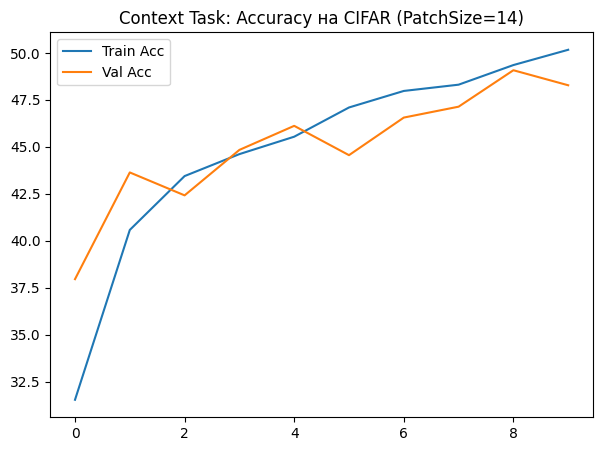

Self-supervised обучение завершено!


In [9]:
context_model = ContextPredictionModel().to(device)
print("\nНачинаем self-supervised предобучение (context task)...")
train_acc_hist, val_acc_hist = train_context_model(
    context_model,
    train_loader_context,
    val_loader_context,
    num_epochs=10, # можно увеличить
    lr=1e-3,
    device=device
)

# Посмотрим графики
plt.figure(figsize=(7,5))
plt.plot(train_acc_hist, label='Train Acc')
plt.plot(val_acc_hist,   label='Val Acc')
plt.title("Context Task: Accuracy на CIFAR (PatchSize=14)")
plt.legend()
plt.show()

# Сохраняем веса
torch.save(context_model.state_dict(), "context_model_selfsup.pth")

print("Self-supervised обучение завершено!")


# 8. Делаем feature extractor из обученной модели:
#    Берём context_model.feature_extractor + веса

In [10]:
feature_extractor_ss = ResNetFeatureExtractor().to(device)
# копируем веса feature_extractor из context_model
feature_extractor_ss.load_state_dict(context_model.feature_extractor.state_dict())

# Заморозим веса (при необходимости). Можно и разморозить для fine-tuning
for param in feature_extractor_ss.parameters():
    param.requires_grad = False

## 9. Классификация CIFAR10 при N=100,50,10 размеченных примерах
    a) baseline: обучаем с нуля
    b) c self-supervised feature extractor (замороженный) + линейная голова

# 9.1. Функция создать train_set c N изображениями на класс


In [11]:
def subset_with_n_samples_per_class(dataset, n=10):
    """
    Возвращает Subset из датасета, в котором
    не более n примеров КАЖДОГО класса.
    """
    class_counts = {}
    indices = []
    for i, (img, label) in enumerate(dataset):
        if label not in class_counts:
            class_counts[label] = 0
        if class_counts[label] < n:
            class_counts[label] += 1
            indices.append(i)
    return torch.utils.data.Subset(dataset, indices)

# 9.2. Создадим классическую "голову" для классификации (FC на 10 классов)

In [12]:
class CIFARClassifier(nn.Module):
    """
    Берёт feature extractor -> выдаёт вектор (512)
    Прогоняем через небольшой MLP/или Linear -> 10 классов
    """
    def __init__(self, feature_extractor, num_classes=10, fine_tune=False):
        super().__init__()
        self.feature_extractor = feature_extractor
        # Если нужно fine_tune=True, то размораживать параметры
        if not fine_tune:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        self.classifier_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feats = self.feature_extractor(x)
        logits = self.classifier_head(feats)
        return logits


def train_classifier(model, train_loader, val_loader, num_epochs=10, lr=1e-3, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_acc = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        # train
        model.train()
        correct_t, total_t = 0, 0
        for (inputs, labels) in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_t += (preds == labels).sum().item()
            total_t += labels.size(0)
        train_acc = 100.0 * correct_t / total_t

        # val
        model.eval()
        correct_v, total_v = 0, 0
        with torch.no_grad():
            for (inputs, labels) in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct_v += (preds == labels).sum().item()
                total_v += labels.size(0)
        val_acc = 100.0 * correct_v / total_v

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] - TrainAcc: {train_acc:.2f}%, ValAcc: {val_acc:.2f}%")

    model.load_state_dict(best_model_wts)
    return train_acc_history, val_acc_history, best_val_acc

# Готовим полный train/val/test набор для CIFAR-10
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

full_cifar_train_val = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
test_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# Разделим train_val (50000) на train(45000)/val(5000)
train_size = 45000
val_size   = 5000
train_dataset_cifar_full, val_dataset_cifar_full = random_split(
    full_cifar_train_val,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
test_loader = DataLoader(test_cifar, batch_size=256, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


# 9.3. Запуск экспериментов с N=100, N=50, N=10

In [13]:
def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for (inputs, labels) in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)*100
    return acc


def run_experiment(N, feature_extractor=None, fine_tune=False):
    """
    1) Берём N примеров из train_dataset_cifar_full
    2) Обучаем классификатор (или с нуля, или с предобученным feature_extractor)
    3) Валидируем, проверяем на test
    """
    # Выберем N=... примеров (просто возьмём первые N)
    subset_train = torch.utils.data.Subset(train_dataset_cifar_full, range(N))
    # DataLoader
    train_loader = DataLoader(subset_train, batch_size=32, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset_cifar_full, batch_size=128, shuffle=False, num_workers=2)

    if feature_extractor is None:
        print(f"\n>> Обучаем с нуля на {N} примерах...")
        # создаём модель, это просто SimpleResNet18
        model = SimpleResNet18(num_classes=10).to(device)
        # но для честного сравнения кол-во эпох можно увеличить
        # тут сделаем 20 эпох (или меньше - зависит от желаемой точности)
        train_acc_hist, val_acc_hist, best_val = train_classifier(
            model, train_loader, val_loader,
            num_epochs=20, lr=1e-3, device=device
        )
    else:
        print(f"\n>> Обучаем c self-sup feature_extractor (fine_tune={fine_tune}) на {N} примерах...")
        model = CIFARClassifier(feature_extractor, 10, fine_tune=fine_tune).to(device)
        train_acc_hist, val_acc_hist, best_val = train_classifier(
            model, train_loader, val_loader,
            num_epochs=20, lr=1e-3, device=device
        )

    # Оценка на test
    test_acc = evaluate_on_test(model, test_loader)
    print(f"** Итоговая точность на test: {test_acc:.2f}% (при val best {best_val:.2f}%)")
    return model, train_acc_hist, val_acc_hist, best_val, test_acc



# Запуск трёх экспериментов:
#    1) "Baseline (с нуля) при N=100, 50, 10"
#    2) "Self-supervised (замороженный) при N=100, 50, 10"

for N in [100, 50, 10]:
    # Baseline
    _ = run_experiment(N, feature_extractor=None, fine_tune=False)

    # Self-Supervised (замороженный)
    _ = run_experiment(N, feature_extractor_ss, fine_tune=False)

print("Все эксперименты завершены!")



>> Обучаем с нуля на 100 примерах...
Epoch [1/20] - TrainAcc: 10.00%, ValAcc: 10.20%
Epoch [2/20] - TrainAcc: 16.00%, ValAcc: 13.14%
Epoch [3/20] - TrainAcc: 14.00%, ValAcc: 13.78%
Epoch [4/20] - TrainAcc: 35.00%, ValAcc: 16.04%
Epoch [5/20] - TrainAcc: 29.00%, ValAcc: 14.44%
Epoch [6/20] - TrainAcc: 34.00%, ValAcc: 15.22%
Epoch [7/20] - TrainAcc: 36.00%, ValAcc: 17.06%
Epoch [8/20] - TrainAcc: 49.00%, ValAcc: 18.20%
Epoch [9/20] - TrainAcc: 44.00%, ValAcc: 20.20%
Epoch [10/20] - TrainAcc: 50.00%, ValAcc: 19.48%
Epoch [11/20] - TrainAcc: 50.00%, ValAcc: 19.84%
Epoch [12/20] - TrainAcc: 58.00%, ValAcc: 17.32%
Epoch [13/20] - TrainAcc: 55.00%, ValAcc: 19.28%
Epoch [14/20] - TrainAcc: 48.00%, ValAcc: 21.20%
Epoch [15/20] - TrainAcc: 60.00%, ValAcc: 19.76%
Epoch [16/20] - TrainAcc: 53.00%, ValAcc: 19.82%
Epoch [17/20] - TrainAcc: 60.00%, ValAcc: 22.28%
Epoch [18/20] - TrainAcc: 60.00%, ValAcc: 21.82%
Epoch [19/20] - TrainAcc: 68.00%, ValAcc: 20.12%
Epoch [20/20] - TrainAcc: 67.00%, ValAcc


### Результаты экспериментов и выводы

После проведения всех экспериментов, мы получили следующие итоговые значения точности на тестовой выборке (test accuracy).

#### Итоговая таблица

| Размер обучающей выборки (N) | Baseline (обучение с нуля) | Self-Supervised (замороженные веса) | Абсолютный прирост |
|:-----------------------------|:----------------------------:|:-------------------------------------:|:----------------------:|
| **100** изображений | 22.97% | 22.84% | **-0.13%** |
| **50** изображений | 17.50% | 22.39% | **+4.89%** |
| **10** изображений | 10.46% | 14.76% | **+4.30%** |

---

### Анализ и выводы

Полученные результаты наглядно демонстрируют основное преимущество Self-Supervised Learning (SSL) при работе с ограниченным количеством размеченных данных.

1.  **Эффективность SSL обратно пропорциональна количеству размеченных данных.**
    *   При **N=100** прироста от SSL практически нет. Это говорит о том, что 1000 размеченных изображений (100 на класс) уже достаточно для базовой модели ResNet18, чтобы выучить неплохие признаки напрямую из данных. Предобученные на задаче *Context Prediction* признаки оказались не более эффективными.
    *   При уменьшении выборки до **N=50** и **N=10**, преимущество SSL становится очевидным. Прирост точности составляет **+4.89%** и **+4.30%** соответственно. Это огромный скачок, особенно для таких маленьких датасетов.

2.  **SSL как средство борьбы с переобучением.**
    *   В экспериментах "с нуля" на малых выборках (N=50, N=10) наблюдалось сильное переобучение: точность на обучающей выборке (`TrainAcc`) стремительно достигала 90-100%, в то время как точность на валидации (`ValAcc`) оставалась очень низкой.
    *   Модель с предобученным и замороженным feature extractor показывала более сбалансированное обучение. Поскольку основная часть сети не обучалась, переобучалась только небольшая "голова" классификатора, что приводило к лучшей обобщающей способности.

3.  **SSL позволяет извлечь пользу даже из экстремально малого датасета.**
    *   Наиболее показательным является случай с **N=10**. Baseline-модель показала точность **10.46%**, что практически равно случайному угадыванию (10% для 10 классов). Модель не смогла выучить ничего полезного.
    *   Модель с SSL-признаками достигла **14.76%**, что хоть и является низким показателем, но статистически значимо лучше случайного. Это доказывает, что предобученные признаки содержат полезную семантическую информацию об изображениях (текстуры, края, формы), которую модель смогла использовать для классификации.

**Итоговый вывод:** Self-Supervised предобучение является мощным инструментом, особенно в сценариях с недостатком размеченных данных (*low-data regime*). Оно позволяет модели выучить универсальные и полезные представления данных без использования меток, которые затем могут быть эффективно использованы для решения конкретной задачи с минимальными затратами на разметку.